# EEG Classification: Alzheimer's Disease vs Healthy Controls (AD vs CN)

**Approach:** XGBoost on hand-crafted EEG features (Relative Band Power + Spectral Coherence Connectivity)

**Pipeline:**
1. Load data locally
2. Subject-level train/test split (no leakage)
3. Downsample 500 Hz → 128 Hz
4. Sliding window (30s windows, 15s overlap)
5. Feature extraction (RBP + SCC per epoch)
6. XGBoost training with group k-fold CV
7. Subject-level prediction aggregation
8. Evaluation + SHAP interpretability

## 0. Install Dependencies

In [2]:
# Run once if needed
# !pip install xgboost shap PyWavelets

## 1. Imports

In [13]:
import numpy as np
import pandas as pd
import pywt
import shap
import matplotlib.pyplot as plt
import os

from scipy.signal import welch, resample
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

np.random.seed(42)

## 2. Configuration

In [14]:
DATA_DIR   = "training"          # root folder with AD/, CN/, FTD/
LABEL_CSV  = "training/train_label_mapping.csv"
ORIG_SFREQ = 500                 # original sampling rate (Hz)
SFREQ      = 128                 # target sampling rate (Hz)
WIN_SEC    = 30                  # window length in seconds
STEP_SEC   = 15                  # step size in seconds
WIN_SAMP   = WIN_SEC  * SFREQ    # samples per window
STEP_SAMP  = STEP_SEC * SFREQ    # samples per step
TEST_SIZE  = 0.2                 # fraction of subjects held out for test
LABEL_MAP  = {'A': 1, 'C': 0}   # AD=1, CN=0

## 3. Helper Functions

In [15]:
def load_npy(path):
    return np.load(path, allow_pickle=True)


def downsample(eeg, orig_fs, target_fs):
    """Resample EEG from orig_fs to target_fs. Input: (channels, time)."""
    n_channels, n_points = eeg.shape
    target_points = int(n_points * target_fs / orig_fs)
    return resample(eeg, target_points, axis=1)


def extract_features(epoch, sfreq):
    """
    Extract RBP and SCC features from a single 30-second epoch.

    Args:
        epoch:  (19, WIN_SAMP) numpy array
        sfreq:  sampling frequency (128 Hz)

    Returns:
        features: 1D array of length (5*19 + 5*19) = 190
    """
    n_channels = epoch.shape[0]
    bands = [(0.5, 4), (4, 8), (8, 13), (13, 25), (25, 45)]

    # --- Relative Band Power (RBP) ---
    freqs, psd = welch(epoch, fs=sfreq, nperseg=sfreq * 2, axis=1)  # (channels, freqs)
    total_power = np.sum(psd, axis=1, keepdims=True)
    total_power[total_power == 0] = 1e-10

    rbp = np.zeros((len(bands), n_channels))
    for b_idx, (fmin, fmax) in enumerate(bands):
        idx = (freqs >= fmin) & (freqs <= fmax)
        rbp[b_idx] = np.sum(psd[:, idx], axis=1) / total_power.flatten()

    # --- Spectral Coherence Connectivity (SCC) via CWT ---
    morlet_freqs = np.array([2, 6, 10, 18, 35])  # one per band
    wavelet_name = 'cmor1.5-1.0'
    center_freq  = pywt.central_frequency(wavelet_name)
    scales       = (center_freq * sfreq) / morlet_freqs

    # CWT per channel: (channels, bands, time)
    coeffs_all = np.zeros((n_channels, len(morlet_freqs), epoch.shape[1]), dtype=np.complex128)
    for ch in range(n_channels):
        cwt_out, _ = pywt.cwt(epoch[ch], scales, wavelet_name, sampling_period=1/sfreq)
        coeffs_all[ch] = cwt_out

    scc = np.zeros((len(morlet_freqs), n_channels))
    for b_idx in range(len(morlet_freqs)):
        seg = coeffs_all[:, b_idx, :]          # (channels, time)
        csd = seg @ seg.conj().T               # (channels, channels)
        psd_vec = np.diag(csd).real
        denom = np.sqrt(np.outer(psd_vec, psd_vec))
        denom[denom == 0] = 1e-10
        coherence = np.abs(csd) / denom
        scc[b_idx] = np.mean(coherence, axis=1)

    # Flatten and concatenate: (5*19,) + (5*19,) = (190,)
    return np.concatenate([rbp.flatten(), scc.flatten()])


def build_feature_names():
    """Human-readable feature names for SHAP plots."""
    channels = ['Fp1','Fp2','F7','F3','Fz','F4','F8','T3','C3','Cz',
                'C4','T4','T5','P3','Pz','P4','T6','O1','O2']
    band_names = ['Delta','Theta','Alpha','Beta','Gamma']
    names = []
    for b in band_names:
        for ch in channels:
            names.append(f'RBP_{b}_{ch}')
    for b in band_names:
        for ch in channels:
            names.append(f'SCC_{b}_{ch}')
    return names


FEATURE_NAMES = build_feature_names()
print(f'Total features per epoch: {len(FEATURE_NAMES)}')

Total features per epoch: 190


## 4. Load Data (AD + CN only)

In [16]:
df_labels = pd.read_csv(LABEL_CSV)

# Keep only AD (A) and CN (C)
df = df_labels[df_labels['label'].isin(['A', 'C'])].reset_index(drop=True)
print(f"Subjects — AD: {(df['label']=='A').sum()}, CN: {(df['label']=='C').sum()}")

subject_ids = []
raw_data    = []
labels      = []

for _, row in df.iterrows():
    sid   = row['anonymized_id']
    label = row['label']
    folder = 'AD' if label == 'A' else 'CN'
    path   = os.path.join(DATA_DIR, folder, f"{sid}.npy")

    if not os.path.exists(path):
        print(f"  Missing: {path}")
        continue

    eeg = load_npy(path)           # (19, time @ 500 Hz)
    eeg = downsample(eeg, ORIG_SFREQ, SFREQ)  # → (19, time @ 128 Hz)

    subject_ids.append(sid)
    raw_data.append(eeg)
    labels.append(LABEL_MAP[label])

print(f"Loaded {len(subject_ids)} subjects")

Subjects — AD: 25, CN: 13
Loaded 38 subjects


## 5. Subject-Level Train / Test Split

All epochs from one subject stay in the same split — this prevents data leakage.

In [17]:
subject_ids = np.array(subject_ids)
labels      = np.array(labels)

splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=42)
train_idx, test_idx = next(splitter.split(subject_ids, labels, groups=subject_ids))

train_subjects = subject_ids[train_idx]
test_subjects  = subject_ids[test_idx]
train_data     = [raw_data[i] for i in train_idx]
test_data      = [raw_data[i] for i in test_idx]
train_labels   = labels[train_idx]
test_labels    = labels[test_idx]

print(f"Train: {len(train_subjects)} subjects  (AD={train_labels.sum()}, CN={(train_labels==0).sum()})")
print(f"Test : {len(test_subjects)} subjects   (AD={test_labels.sum()}, CN={(test_labels==0).sum()})")

Train: 30 subjects  (AD=24, CN=6)
Test : 8 subjects   (AD=1, CN=7)


## 6. Feature Extraction (Sliding Window)

For each subject, slide a 30s window (step 15s) and extract a 190-dim feature vector per epoch.

In [18]:
def extract_all_epochs(data_list, subject_ids, subject_labels):
    """Returns X (n_epochs, 190), y (n_epochs,), groups (n_epochs,)."""
    X_list, y_list, g_list = [], [], []

    for eeg, sid, label in zip(data_list, subject_ids, subject_labels):
        n_points = eeg.shape[1]
        epoch_count = 0

        for start in range(0, n_points - WIN_SAMP + 1, STEP_SAMP):
            epoch = eeg[:, start : start + WIN_SAMP]
            feats = extract_features(epoch, SFREQ)
            X_list.append(feats)
            y_list.append(label)
            g_list.append(sid)
            epoch_count += 1

        print(f"  Subject {sid}: {epoch_count} epochs")

    return np.array(X_list), np.array(y_list), np.array(g_list)


print("Extracting training features...")
X_train, y_train, groups_train = extract_all_epochs(train_data, train_subjects, train_labels)

print("\nExtracting test features...")
X_test, y_test, groups_test = extract_all_epochs(test_data, test_subjects, test_labels)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

Extracting training features...
  Subject 3: 14 epochs
  Subject 4: 9 epochs
  Subject 8: 12 epochs
  Subject 9: 13 epochs
  Subject 18: 13 epochs
  Subject 24: 13 epochs
  Subject 27: 12 epochs
  Subject 28: 13 epochs
  Subject 30: 13 epochs
  Subject 32: 11 epochs
  Subject 34: 11 epochs
  Subject 40: 20 epochs
  Subject 42: 13 epochs
  Subject 44: 12 epochs
  Subject 46: 14 epochs
  Subject 48: 12 epochs
  Subject 50: 11 epochs
  Subject 51: 4 epochs
  Subject 52: 11 epochs
  Subject 53: 12 epochs
  Subject 55: 15 epochs
  Subject 56: 9 epochs
  Subject 61: 8 epochs
  Subject 70: 11 epochs
  Subject 73: 13 epochs
  Subject 76: 12 epochs
  Subject 78: 13 epochs
  Subject 82: 13 epochs
  Subject 84: 12 epochs
  Subject 86: 18 epochs

Extracting test features...
  Subject 10: 14 epochs
  Subject 23: 11 epochs
  Subject 39: 14 epochs
  Subject 64: 13 epochs
  Subject 69: 15 epochs
  Subject 75: 14 epochs
  Subject 81: 12 epochs
  Subject 85: 15 epochs

X_train: (367, 190), X_test: (108,

## 7. Feature Scaling

In [19]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 8. Cross-Validation (Group K-Fold on Training Set)

Group K-Fold ensures no subject appears in both the CV train and validation fold.

In [20]:
gkf = GroupKFold(n_splits=5)

cv_acc, cv_f1 = [], []

for fold, (tr, val) in enumerate(gkf.split(X_train, y_train, groups=groups_train)):
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train[tr], y_train[tr])
    preds = model.predict(X_train[val])
    acc = accuracy_score(y_train[val], preds)
    f1  = f1_score(y_train[val], preds)
    cv_acc.append(acc)
    cv_f1.append(f1)
    print(f"Fold {fold+1}: Accuracy={acc:.3f}  F1={f1:.3f}")

print(f"\nMean CV Accuracy: {np.mean(cv_acc):.3f} ± {np.std(cv_acc):.3f}")
print(f"Mean CV F1:       {np.mean(cv_f1):.3f} ± {np.std(cv_f1):.3f}")

/Users/maeshamahmud/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [12:07:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 1: Accuracy=0.792  F1=0.884


/Users/maeshamahmud/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [12:07:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 2: Accuracy=0.853  F1=0.895


/Users/maeshamahmud/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [12:07:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 3: Accuracy=0.918  F1=0.952


/Users/maeshamahmud/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [12:07:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 4: Accuracy=0.534  F1=0.667


/Users/maeshamahmud/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [12:07:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 5: Accuracy=0.959  F1=0.979

Mean CV Accuracy: 0.811 ± 0.150
Mean CV F1:       0.875 ± 0.110


## 9. Train Final Model on All Training Data

In [21]:
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)
print("Final model trained.")

/Users/maeshamahmud/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [12:09:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Final model trained.


## 10. Subject-Level Prediction Aggregation

Average epoch probabilities per subject → threshold at 0.5 for final label.

In [22]:
def subject_level_predictions(model, X, groups, true_labels_per_epoch):
    """
    Aggregates epoch-level probabilities to subject-level predictions.

    Returns:
        subject_ids:    unique subject IDs
        y_true:         true label per subject
        y_pred:         predicted label per subject (majority vote via avg prob)
        y_prob:         average predicted probability per subject
    """
    probs = model.predict_proba(X)[:, 1]   # P(AD) per epoch

    subj_ids, y_true, y_pred, y_prob = [], [], [], []

    for sid in np.unique(groups):
        mask      = groups == sid
        avg_prob  = probs[mask].mean()
        pred      = int(avg_prob >= 0.5)
        true_lbl  = true_labels_per_epoch[mask][0]

        subj_ids.append(sid)
        y_true.append(true_lbl)
        y_pred.append(pred)
        y_prob.append(avg_prob)

    return np.array(subj_ids), np.array(y_true), np.array(y_pred), np.array(y_prob)


sids, y_true, y_pred, y_prob = subject_level_predictions(
    final_model, X_test, groups_test, y_test
)

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred)
print(f"Subject-level Test Accuracy: {acc:.3f}")
print(f"Subject-level Test F1:       {f1:.3f}")

Subject-level Test Accuracy: 0.625
Subject-level Test F1:       0.400


## 11. Confusion Matrix

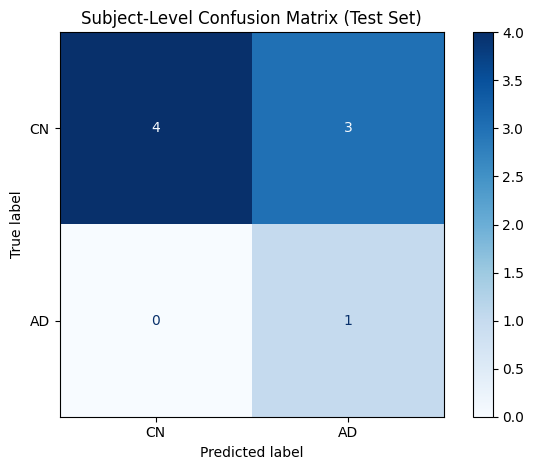

In [23]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CN', 'AD'])
disp.plot(cmap='Blues')
plt.title('Subject-Level Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 12. Interpretability — SHAP Feature Importance

Shows which EEG frequency bands and electrodes drive AD classification.

/var/folders/1d/9k06_3n175136bzl5hzwgqwm0000gn/T/ipykernel_99170/443492238.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


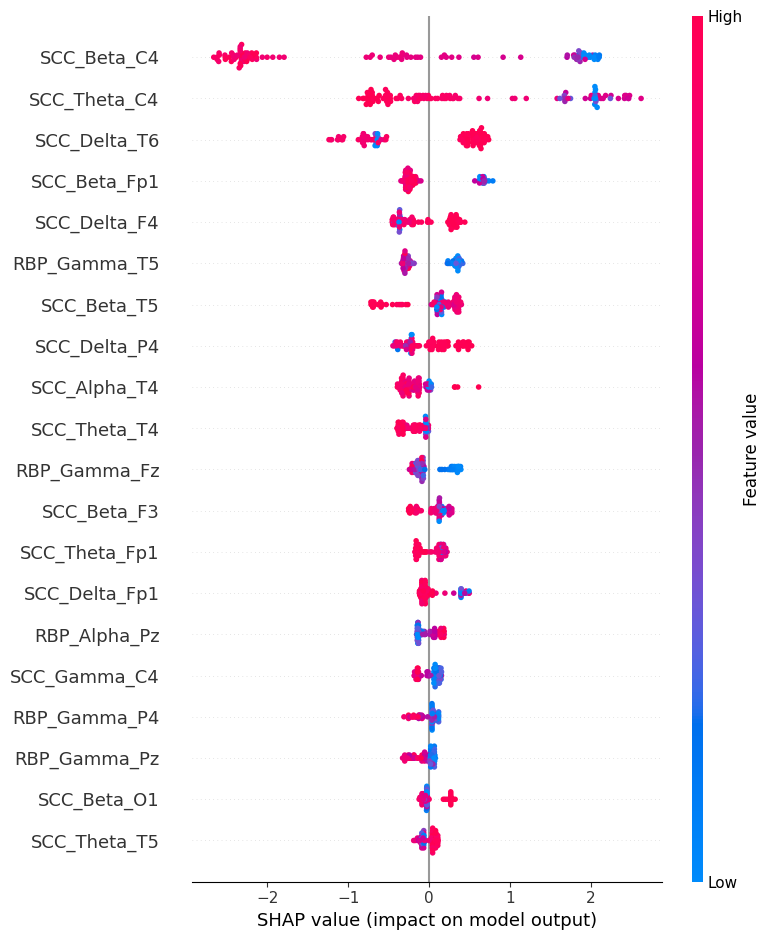

In [24]:
explainer  = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — top 20 features
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=True
)

/var/folders/1d/9k06_3n175136bzl5hzwgqwm0000gn/T/ipykernel_99170/2477930894.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


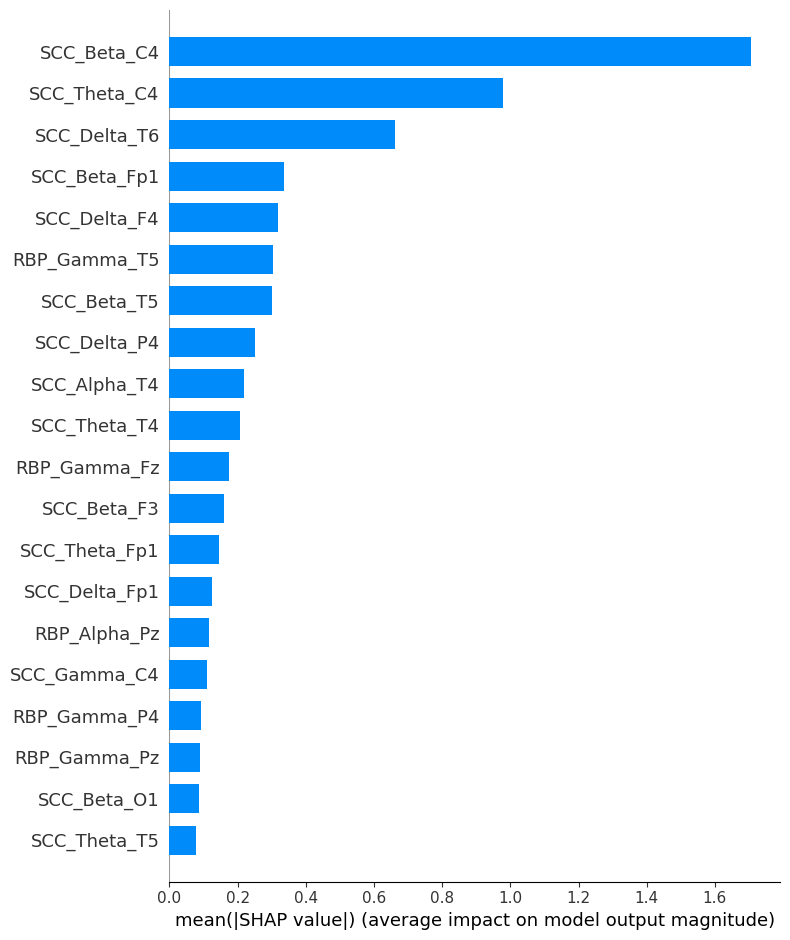

In [25]:
# Bar chart — mean absolute SHAP per feature (top 20)
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_NAMES,
    plot_type='bar',
    max_display=20,
    show=True
)

## 13. Band Power Visualization (EDA)

Compare average relative band power across AD and CN subjects.

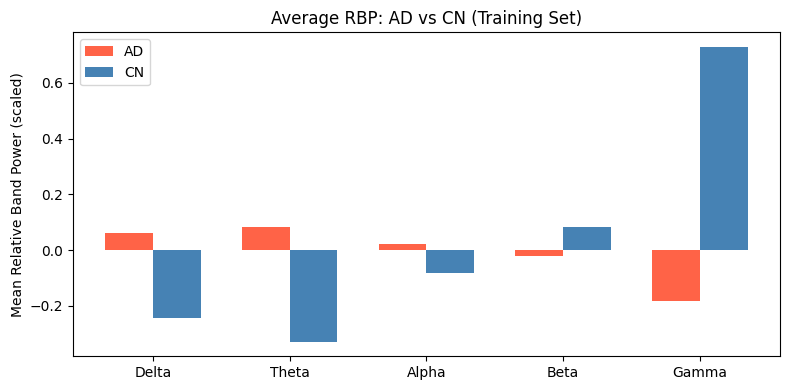

In [26]:
band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
n_bands    = len(band_names)
n_channels = 19

# RBP features are the first 5*19 = 95 columns
rbp_all = X_train[:, :n_bands * n_channels].reshape(-1, n_bands, n_channels)

ad_mask = y_train == 1
cn_mask = y_train == 0

rbp_ad = rbp_all[ad_mask].mean(axis=(0, 2))   # mean over epochs and channels
rbp_cn = rbp_all[cn_mask].mean(axis=(0, 2))

x = np.arange(n_bands)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, rbp_ad, width, label='AD', color='tomato')
ax.bar(x + width/2, rbp_cn, width, label='CN', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(band_names)
ax.set_ylabel('Mean Relative Band Power (scaled)')
ax.set_title('Average RBP: AD vs CN (Training Set)')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Inference on Test Data (When Released)

Run this cell when the test `.npy` files are available.

In [ ]:
# ---------------------------------------------------------------
# Update TEST_DATA_DIR to point to the released test folder
# ---------------------------------------------------------------
TEST_DATA_DIR = "test"   # folder containing test .npy files

test_files = [f for f in os.listdir(TEST_DATA_DIR) if f.endswith('.npy')]
test_sids, test_eegs = [], []

for fname in test_files:
    sid = int(fname.replace('.npy', ''))
    eeg = load_npy(os.path.join(TEST_DATA_DIR, fname))
    eeg = downsample(eeg, ORIG_SFREQ, SFREQ)
    test_sids.append(sid)
    test_eegs.append(eeg)

# Extract features
X_inf_list, g_inf_list = [], []
for eeg, sid in zip(test_eegs, test_sids):
    n_points = eeg.shape[1]
    for start in range(0, n_points - WIN_SAMP + 1, STEP_SAMP):
        epoch = eeg[:, start : start + WIN_SAMP]
        X_inf_list.append(extract_features(epoch, SFREQ))
        g_inf_list.append(sid)

X_inf = scaler.transform(np.array(X_inf_list))
g_inf = np.array(g_inf_list)

# Subject-level predictions
probs_inf = final_model.predict_proba(X_inf)[:, 1]
results = []
for sid in np.unique(g_inf):
    mask     = g_inf == sid
    avg_prob = probs_inf[mask].mean()
    pred     = 'A' if avg_prob >= 0.5 else 'C'
    results.append({'anonymized_id': sid, 'label': pred, 'prob_AD': avg_prob})

df_out = pd.DataFrame(results)
df_out.to_csv('predictions.csv', index=False)
print(df_out)
print("Saved to predictions.csv")

ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.